# 5.2. Implementation of Multilayer Perceptrons

Let's train our first deep neural network on the Fashion MNIST dataset we saw in earlier chapters. It's not much different than simple linear models except now we have multiple layers with activation functions between consecutive layers for non-linearity.

In [1]:
import mindspore

mindspore.set_device(device_target='Ascend', device_id=0)
mindspore.run_check()

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangepiaipro-20t/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangep

MindSpore version:  2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!


## 5.2.2. Concise Implementation

In previous chapters, we defined our model as a subclass of [`mindspore.nn.Cell`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/nn/mindspore.nn.Cell.html) and manually constructed our network via the `construct` method. Furthermore, we explicitly defined each layer to use 16-bit floating point values \(FP16\) as supported by Ascend NPUs and defined our training and validation loop in a rather manual and low-level fashion.

Since we've done this multiple times already and should already be familiar with the basics, we'll start leveraging more syntactic sugar from here onwards and leverage the high-level APIs provided by MindSpore 2.8.0.

1. Define our neural networks directly as a sequence of applied layers with [`mindspore.nn.SequentialCell`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/nn/mindspore.nn.SequentialCell.html) instead of constructing the network manually per step
1. Use automatic mixed precision \(AMP\) to handle casting between FP32 and FP16 automatically with [`mindspore.amp.auto_mixed_precision`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/amp/mindspore.amp.auto_mixed_precision.html#mindspore.amp.auto_mixed_precision)
1. Invoke the training loop automatically with the MindSpore Model API: [`mindspore.train.Model`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/train/mindspore.train.Model.html#mindspore.train.Model)

### 5.2.2.1. Model

Let's define our deep neural network as follows.

1. Use [`mindspore.nn.Flatten`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/nn/mindspore.nn.Flatten.html) to transform our images to a flat layer of $28 \times 28 \times 1 = 784$ input features. It's a more flexible and generic version of the `mindspore.ops.Flatten` we saw earlier which allows us to define which dimensions to flatten on, though the default values suffice for our use case
1. Apply a hidden layer with $784$ input channels and $2^8=256$ output channels plus ReLU activation. Choosing powers of 2 for our hidden layers ensures our matrices are memory-aligned for improved training performance. ReLU activation introduces non-linearity to our hidden outputs and helps us learn a _hidden representation_ of our data to feed into our final, linear layer
1. Apply a fully connected layer with $2^8=256$ input channels and $10$ output channels. Each output channel corresponds to a label in our dataset

In [2]:
import mindspore.nn as nn

net = nn.SequentialCell([
    nn.Flatten(),
    nn.Dense(784, 256, activation='relu'),
    nn.Dense(256, 10)
])
net

SequentialCell(
  (0): Flatten()
  (1): Dense(
    input_channels=784, output_channels=256, has_bias=True, activation=ReLU()
    (activation): ReLU()
  )
  (2): Dense(input_channels=256, output_channels=10, has_bias=True)
)

### 5.2.2.2. Training

Let's train our first deep neural network. But before that, let's load, visualize and transform our Fashion MNIST dataset.

In [3]:
import os

dataset_dir = 'data/fashion/'
os.makedirs(dataset_dir, exist_ok=True)

In [4]:
import gzip
import urllib.request

X_train_url = 'http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-images-idx3-ubyte.gz'
y_train_url = 'http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-labels-idx1-ubyte.gz'
X_test_url = 'http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-images-idx3-ubyte.gz'
y_test_url = 'http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-labels-idx1-ubyte.gz'

X_train_path = os.path.join(dataset_dir, 'train-images-idx3-ubyte')
y_train_path = os.path.join(dataset_dir, 'train-labels-idx1-ubyte')
X_test_path = os.path.join(dataset_dir, 't10k-images-idx3-ubyte')
y_test_path = os.path.join(dataset_dir, 't10k-labels-idx1-ubyte')

with urllib.request.urlopen(X_train_url) as response:
    with open(X_train_path, 'wb') as out_file:
        data_gzip = response.read()
        data = gzip.decompress(data_gzip)
        out_file.write(data)

with urllib.request.urlopen(y_train_url) as response:
    with open(y_train_path, 'wb') as out_file:
        data_gzip = response.read()
        data = gzip.decompress(data_gzip)
        out_file.write(data)

with urllib.request.urlopen(X_test_url) as response:
    with open(X_test_path, 'wb') as out_file:
        data_gzip = response.read()
        data = gzip.decompress(data_gzip)
        out_file.write(data)

with urllib.request.urlopen(y_test_url) as response:
    with open(y_test_path, 'wb') as out_file:
        data_gzip = response.read()
        data = gzip.decompress(data_gzip)
        out_file.write(data)

In [5]:
import mindspore.dataset as ds

visualization_ds = ds.FashionMnistDataset(dataset_dir=dataset_dir, usage='train', shuffle=True)
train_ds = ds.FashionMnistDataset(dataset_dir=dataset_dir, usage='train', shuffle=True)
test_ds = ds.FashionMnistDataset(dataset_dir=dataset_dir, usage='test', shuffle=True)

In [6]:
visualization_ds_samples = visualization_ds.batch(batch_size=10)

In [7]:
X_samples, y_samples = next(visualization_ds_samples.create_tuple_iterator())
X_samples, y_samples = X_samples.asnumpy(), y_samples.asnumpy()
X_samples.shape, y_samples.shape

((10, 28, 28, 1), (10,))

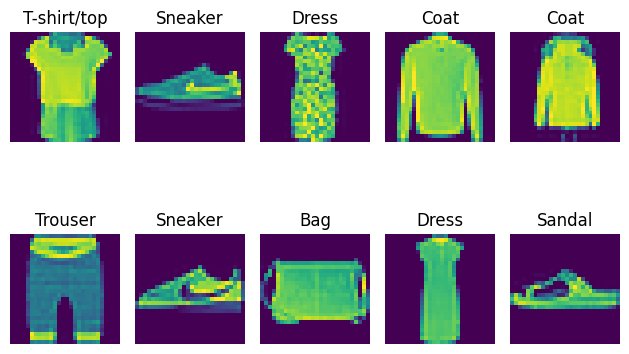

In [8]:
import matplotlib.pyplot as plt

LABELS = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

fig, axes = plt.subplots(2, 5)
for axis_idx, axis in enumerate(axes.flatten()):
    axis.set_title(LABELS[y_samples[axis_idx]])
    axis.imshow(X_samples[axis_idx])
    axis.axis('off')
fig.tight_layout()
fig.show()

In [9]:
import mindspore.dataset.vision as vision
import mindspore.dataset.transforms as transforms
from mindspore import dtype as mstype

def transform_ds(dataset):
    image_transforms = [
        vision.Resize(size=(28, 28)),
        vision.Rescale(rescale=1/255, shift=0),
        vision.HWC2CHW()
    ]
    label_transforms = [
        transforms.OneHot(num_classes=10),
        transforms.TypeCast(data_type=mstype.float32)
    ]
    dataset = dataset.map(operations=image_transforms, input_columns='image')
    dataset = dataset.map(operations=label_transforms, input_columns='label')
    return dataset

train_ds, test_ds = transform_ds(dataset=train_ds), transform_ds(dataset=test_ds)
train_ds = train_ds.batch(batch_size=512, drop_remainder=False)

With the standard image transformations applied to our dataset, let's get straight to training our first deep neural network!

Define our AMP level `O2`. It casts operations to FP16 except critical layers such as batch and layer normalization. Critical layers retain full FP32 precision.

In [10]:
import mindspore.amp as amp

amp_level = 'O2'
net_amp = amp.auto_mixed_precision(network=net, amp_level=amp_level)
net_amp

_OutputTo32(
  (_backbone): SequentialCell(
    (0): Flatten()
    (1): Dense(
      input_channels=784, output_channels=256, has_bias=True, activation=ReLU()
      (activation): ReLU()
    )
    (2): Dense(input_channels=256, output_channels=10, has_bias=True)
  )
)

Next, define the combined activation and loss function as well as our optimizer.

1. Combined activation and loss function: `mindspore.nn.SoftmaxCrossEntropyWithLogits`
1. Optimization algorithm: minibatch SGD

In [11]:
loss_fn = nn.SoftmaxCrossEntropyWithLogits(reduction='mean')
loss_fn

SoftmaxCrossEntropyWithLogits()

In [12]:
optimizer = nn.SGD(params=net_amp.trainable_params(), learning_rate=0.1)
optimizer

SGD()

Finally, wrap our neural network with built-in training and inference features using [`mindspore.train.Model`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/train/mindspore.train.Model.html#mindspore.train.Model) and invoke the `train` method with the specified number of epochs: $20$.

In [13]:
from mindspore.train import Model, LossMonitor

model = Model(network=net_amp, loss_fn=loss_fn, optimizer=optimizer)
model

In [14]:
epochs = 20

In [15]:
model.train(epoch=epochs,
            train_dataset=train_ds,
            callbacks=[LossMonitor()])

/usr/local/Ascend/cann-8.5.0/python/site-packages/asc_op_compile_base/asc_op_compiler/ascendc_compile_gen_code.py:161: SyntaxWarning: invalid escape sequence '\w'
  match = re.search(f'{option}=(\w+)', ' '.join(compile_options))
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/c

.epoch: 1 step: 1, loss is 2.318540573120117
epoch: 1 step: 2, loss is 2.253788948059082
epoch: 1 step: 3, loss is 2.211099624633789
epoch: 1 step: 4, loss is 2.162689447402954
epoch: 1 step: 5, loss is 2.1119985580444336
epoch: 1 step: 6, loss is 2.055652618408203
epoch: 1 step: 7, loss is 2.019249439239502
epoch: 1 step: 8, loss is 1.9825676679611206
epoch: 1 step: 9, loss is 1.924394965171814
epoch: 1 step: 10, loss is 1.8754315376281738
epoch: 1 step: 11, loss is 1.8126609325408936
epoch: 1 step: 12, loss is 1.768255352973938
epoch: 1 step: 13, loss is 1.7569769620895386
epoch: 1 step: 14, loss is 1.6997034549713135
epoch: 1 step: 15, loss is 1.6573837995529175
epoch: 1 step: 16, loss is 1.590306282043457
epoch: 1 step: 17, loss is 1.5502729415893555
epoch: 1 step: 18, loss is 1.5264575481414795
epoch: 1 step: 19, loss is 1.4439915418624878
epoch: 1 step: 20, loss is 1.4545834064483643
epoch: 1 step: 21, loss is 1.4043452739715576
epoch: 1 step: 22, loss is 1.376605749130249
epoch:

Let's now use our trained model to predict labels on our validation set and compute the validation loss and accuracy. 

In [16]:
test_ds = test_ds.batch(batch_size=10000)
X_test, y_test = next(test_ds.create_tuple_iterator())
X_test.shape, y_test.shape

((10000, 1, 28, 28), (10000, 10))

In [17]:
y_hat = model.predict(X_test)
y_hat.shape

(10000, 10)

In [18]:
validation_loss = loss_fn(y_hat, y_test)
print(f'Validation loss: {validation_loss.asnumpy():.4f}')

Validation loss: 0.4128


In [19]:
import mindspore.ops as ops

y_hat, y_test = ops.argmax(y_hat, dim=1), ops.argmax(y_test, dim=1)
y_hat.shape, y_test.shape

.

((10000,), (10000,))

In [20]:
total = 10000
correct = (y_hat == y_test).sum().item()
validation_accuracy = correct / total
print(f'Validation accuracy: {validation_accuracy}')

Validation accuracy: 0.8533


The validation accuracy is around $85\%$ - not too bad! Recall that our simple linear classification model scored just over $80\%$ so we get a noticeable improvement using a deep neural network.

## 5.2.3. Summary

We saw in this chapter how to train our first deep neural network. We also saw how to leverage AMP to handle type conversions between FP32 and FP16 automatically and how to leverage MindSpore's high-level Model API for model training and inference.